# 01. Neural Networks

**Tier:** Foundations
**Estimated time:** 45 minutes
**Prerequisites:** 00
**Source material:** @sairahul1 — "20 AI Concepts You Must Understand in 2026" (https://x.com/sairahul1/status/2057740928908161461)

## What You'll Learn
- What a neuron actually computes — and why stacking them lets a network learn curves
- How a network *learns*: forward pass → loss → backpropagation → gradient descent, implemented from scratch in NumPy
- How the same model looks in PyTorch, and why autograd exists

## Why This Matters
Every model in this curriculum — from a tiny classifier to a 2-billion-parameter LLM — is the same three ideas repeated: a forward pass that makes a prediction, a loss that scores it, and gradients that nudge the weights. If you understand them on a 2-input toy problem, the transformer in notebook 05 is just *more of the same*.

## The big idea, in plain English

A **neuron** is a tiny voting machine. It takes some inputs, multiplies each by a *weight* (how much that input matters), adds them up, adds a *bias* (a baseline nudge), and then passes the result through an **activation function** that decides how strongly to "fire."

One neuron can only draw a straight line. The magic is **stacking**: feed the outputs of one layer of neurons into another. A hidden layer with a non-linear activation lets the network bend that line into arbitrary curves — enough to separate tangled data that no straight line could.

**Learning** = finding the weights. We do it by:
1. **Forward pass** — run the inputs through to get a prediction.
2. **Loss** — measure how wrong the prediction is (one number).
3. **Backpropagation** — use calculus (the chain rule) to compute how each weight contributed to the error.
4. **Gradient descent** — nudge every weight a little in the direction that reduces the loss. Repeat thousands of times.

That's it. Everything below is this loop, made concrete.

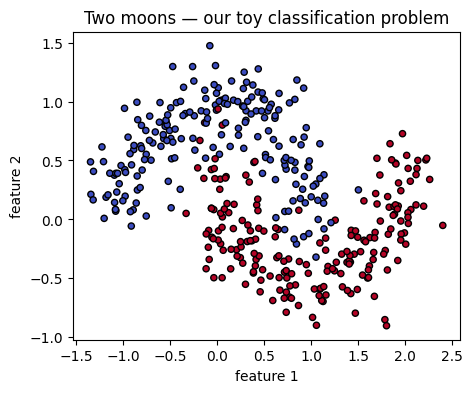

X: (400, 2)  y: (400, 1)


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

np.random.seed(0)

# Two interleaving half-moons — NOT separable by a straight line.
X, y = make_moons(n_samples=400, noise=0.20, random_state=0)
y = y.reshape(-1, 1)              # shape (400, 1) so it lines up with our network output

plt.figure(figsize=(5, 4))
plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap="coolwarm", edgecolors="k", s=20)
plt.title("Two moons — our toy classification problem")
plt.xlabel("feature 1"); plt.ylabel("feature 2")
plt.show()
print("X:", X.shape, " y:", y.shape)

*The two classes are tangled — a single straight line can't separate them. We'll need a hidden layer with a non-linear activation.*

## A single neuron, then a layer

A layer of `H` neurons over `D` inputs is just a matrix multiply plus a bias:

```
z = X @ W + b          # W has shape (D, H), b has shape (1, H)
a = activation(z)
```

`X @ W` does all the "multiply each input by its weight and sum" for every neuron and every example at once. We'll use **tanh** for the hidden layer (smooth, non-linear) and a **sigmoid** at the output to squash the answer into a 0–1 probability.

In [2]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def tanh(z):
    return np.tanh(z)

# We initialise weights small and random so neurons start out different from each other.
def init_params(n_in, n_hidden, n_out=1):
    rng = np.random.default_rng(42)
    return {
        "W1": rng.normal(0, 0.5, size=(n_in, n_hidden)),
        "b1": np.zeros((1, n_hidden)),
        "W2": rng.normal(0, 0.5, size=(n_hidden, n_out)),
        "b2": np.zeros((1, n_out)),
    }

def forward(params, X):
    z1 = X @ params["W1"] + params["b1"]   # pre-activation, hidden layer
    a1 = tanh(z1)                          # hidden activation
    z2 = a1 @ params["W2"] + params["b2"]  # pre-activation, output
    a2 = sigmoid(z2)                       # predicted probability of class 1
    cache = (z1, a1, z2, a2)               # we'll need these for backprop
    return a2, cache

params = init_params(n_in=2, n_hidden=8)
preds, _ = forward(params, X)
print("Predictions before training (first 5):", preds[:5].ravel().round(3))

Predictions before training (first 5): [0.503 0.697 0.69  0.328 0.475]


## Loss and backpropagation

For binary classification we use **binary cross-entropy** loss — it's large when the predicted probability is far from the true label and near zero when it's right.

Backprop is the chain rule applied layer by layer, *backwards*. The derivations below are standard; the key intuition is that each line answers "how much does this quantity affect the loss?" and passes that signal one layer further back.

In [3]:
def bce_loss(y_true, y_pred):
    eps = 1e-9                              # avoid log(0)
    return -np.mean(y_true * np.log(y_pred + eps) + (1 - y_true) * np.log(1 - y_pred + eps))

def backward(params, cache, X, y):
    z1, a1, z2, a2 = cache
    m = X.shape[0]                          # number of examples (for averaging)

    # Output layer. For sigmoid + BCE the gradient simplifies beautifully to (pred - true).
    dz2 = (a2 - y) / m
    dW2 = a1.T @ dz2
    db2 = dz2.sum(axis=0, keepdims=True)

    # Hidden layer. Propagate the error back through W2, then through tanh's derivative (1 - tanh^2).
    da1 = dz2 @ params["W2"].T
    dz1 = da1 * (1 - np.tanh(z1) ** 2)
    dW1 = X.T @ dz1
    db1 = dz1.sum(axis=0, keepdims=True)

    return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}

## The training loop

Gradient descent in one line per parameter: `W -= learning_rate * gradient`. We repeat for many *epochs* (full passes over the data) and watch the loss fall.

In [4]:
def train(X, y, n_hidden=8, lr=1.0, epochs=2000):
    params = init_params(n_in=X.shape[1], n_hidden=n_hidden)
    history = []
    for epoch in range(epochs):
        preds, cache = forward(params, X)          # 1. forward
        loss = bce_loss(y, preds)                  # 2. loss
        grads = backward(params, cache, X, y)      # 3. backprop
        for key in params:                         # 4. gradient descent
            params[key] -= lr * grads[key]
        if epoch % 200 == 0:
            history.append((epoch, loss))
            print(f"epoch {epoch:4d}   loss {loss:.4f}")
    return params, history

trained, history = train(X, y, n_hidden=8, lr=1.0, epochs=2000)

epoch    0   loss 0.6525
epoch  200   loss 0.1934
epoch  400   loss 0.1215
epoch  600   loss 0.1026
epoch  800   loss 0.0945
epoch 1000   loss 0.0907
epoch 1200   loss 0.0887
epoch 1400   loss 0.0874
epoch 1600   loss 0.0865
epoch 1800   loss 0.0857


Training accuracy: 96.8%


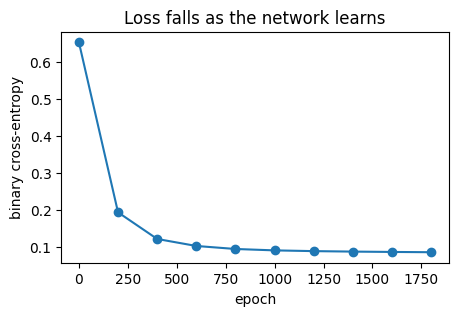

In [5]:
# Final accuracy
final_preds, _ = forward(trained, X)
accuracy = np.mean((final_preds > 0.5) == y)
print(f"Training accuracy: {accuracy:.1%}")

epochs_h, losses_h = zip(*history)
plt.figure(figsize=(5, 3))
plt.plot(epochs_h, losses_h, marker="o")
plt.title("Loss falls as the network learns")
plt.xlabel("epoch"); plt.ylabel("binary cross-entropy")
plt.show()

*The loss drops sharply then flattens — the network has found weights that separate the moons.*

## Seeing what it learned: the decision boundary

We sweep a grid over the input space, ask the network for its prediction at every point, and colour the background by its answer. The curved boundary is what the hidden layer's non-linearity bought us — a straight-line model could never draw this.

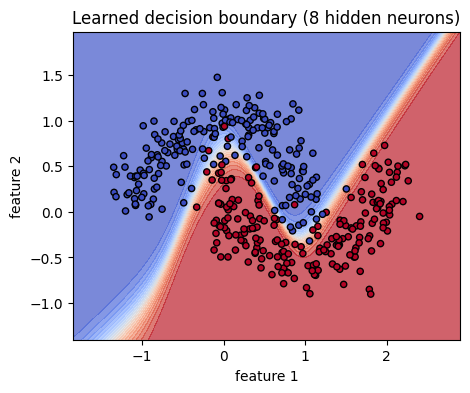

In [6]:
def plot_boundary(params, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    probs, _ = forward(params, grid)
    plt.figure(figsize=(5, 4))
    plt.contourf(xx, yy, probs.reshape(xx.shape), levels=20, cmap="coolwarm", alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap="coolwarm", edgecolors="k", s=20)
    plt.title(title); plt.xlabel("feature 1"); plt.ylabel("feature 2")
    plt.show()

plot_boundary(trained, X, y, "Learned decision boundary (8 hidden neurons)")

*The background colour is the network's predicted class everywhere in the plane. Notice the curve — that's non-linearity at work.*

## The same thing in PyTorch

We wrote forward and backward by hand to demystify them. In practice, **autograd** does the backward pass for you: you only write the forward pass, call `loss.backward()`, and PyTorch fills in every gradient via the chain rule automatically. This is the exact mechanism that scales to billion-parameter models.

In [7]:
import torch
import torch.nn as nn

Xt = torch.tensor(X, dtype=torch.float32)
yt = torch.tensor(y, dtype=torch.float32)

model = nn.Sequential(
    nn.Linear(2, 8),   # hidden layer: 2 inputs -> 8 neurons
    nn.Tanh(),
    nn.Linear(8, 1),   # output layer: 8 -> 1
    nn.Sigmoid(),
)
loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1.0)

for epoch in range(2000):
    optimizer.zero_grad()
    preds = model(Xt)            # forward — the ONLY pass we write
    loss = loss_fn(preds, yt)
    loss.backward()              # autograd computes every gradient for us
    optimizer.step()             # gradient descent update
    if epoch % 500 == 0:
        print(f"epoch {epoch:4d}   loss {loss.item():.4f}")

acc = ((model(Xt) > 0.5) == yt.bool()).float().mean()
print(f"PyTorch training accuracy: {acc.item():.1%}")

epoch    0   loss 0.7692
epoch  500   loss 0.2874
epoch 1000   loss 0.0949
epoch 1500   loss 0.0863


PyTorch training accuracy: 96.7%


## Exercises

In [8]:
# Exercise 1 (Warm-up): Hidden-layer width
# Task: Re-train the NumPy network with n_hidden = 1, then 2, then 16, and compare
#       the final training accuracy and the decision boundary.
# Hint: Call train(...) with a different n_hidden, then plot_boundary(...). What's the
#       smallest width that still separates the moons?

# YOUR CODE HERE

In [9]:
# Exercise 2 (Apply): Add ReLU
# Task: Implement a relu(z) function and its derivative, and swap it in for tanh in a
#       copy of forward()/backward(). Train and compare convergence speed.
# Hint: relu(z) = max(0, z); its derivative is 1 where z > 0 and 0 elsewhere.

# YOUR CODE HERE

In [10]:
# Exercise 3 (Extend): Connect to LLMs
# Task: A transformer block (notebook 05) is mostly Linear layers + a non-linearity,
#       just like this network. Count the parameters in our 2->8->1 model BY HAND
#       (weights + biases), then verify with: sum(p.numel() for p in model.parameters()).
# Hint: A Linear(a, b) layer has a*b weights and b biases.

# YOUR CODE HERE

<details>
<summary>Show solutions</summary>

```python
# Exercise 1
for h in [1, 2, 16]:
    p, _ = train(X, y, n_hidden=h, lr=1.0, epochs=2000)
    pred, _ = forward(p, X)
    print(h, "hidden ->", np.mean((pred > 0.5) == y))
    plot_boundary(p, X, y, f"{h} hidden neurons")
# 1 neuron can only draw a line (~85%); ~3+ neurons are enough to bend around the moons.

# Exercise 2
def relu(z):            return np.maximum(0, z)
def relu_grad(z):       return (z > 0).astype(float)
# In forward(): a1 = relu(z1).  In backward(): dz1 = da1 * relu_grad(z1).
# ReLU often converges faster and is the default in modern deep nets.

# Exercise 3
# By hand: W1 = 2*8 = 16, b1 = 8, W2 = 8*1 = 8, b2 = 1  ->  33 parameters.
print(sum(p.numel() for p in model.parameters()))   # 33
```
</details>

## Key Takeaways
- A neuron computes `activation(inputs · weights + bias)`; stacking neurons with a non-linear activation lets a network learn curves, not just lines.
- Learning is a loop: **forward → loss → backprop → gradient descent**, repeated. We implemented all four from scratch in NumPy.
- Backprop is just the chain rule applied backwards through the layers; **autograd** (PyTorch) automates it so you only write the forward pass.
- The number of hidden neurons controls model capacity — too few underfits, and more isn't always better.

## What's Next
Notebook **02 — Tokenization** tackles the first thing an LLM actually does to your text: chop it into tokens. Neural nets eat numbers, not strings — tokenization is the bridge.